In [96]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [97]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input, Flatten

In [98]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

In [99]:
X_train

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [100]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_train.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (60000,)


In [101]:
X_train[0] #1st row image

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [102]:
y_train

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

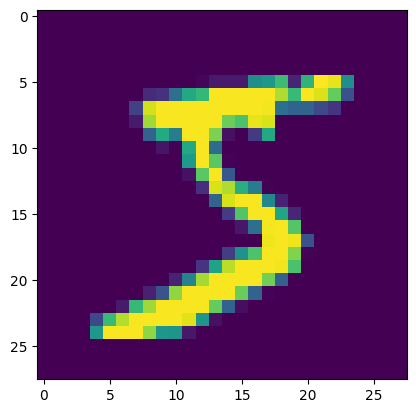

In [103]:
import matplotlib.pyplot as plt
plt.imshow(X_train[0])

In [104]:
# Scaling (values are from range 0 to 255)
X_train = X_train/255
X_test = X_test/255

In [105]:
# Now all values should be between 0 and 1
X_train[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [106]:
model = Sequential()

# Layer 0 
model.add(Input(shape = (28, 28)))
# (Flatten the 2D to 1D)
model.add(Flatten())
# Layer 1
model.add(Dense(128, activation = 'relu'))
# Layer 2 Output Layer
model.add(Dense(10, activation = 'softmax')) # for multiclass

In [107]:
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_7 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [108]:
# Compile the model with loss function and optimizer
model.compile(loss = 'sparse_categorical_crossentropy', optimizer = 'Adam', metrics = ['accuracy'])

In [109]:
# Training
history = model.fit(X_train, y_train, epochs = 25, validation_split = 0.2)

Epoch 1/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9169 - loss: 0.2873 - val_accuracy: 0.9574 - val_loss: 0.1520
Epoch 2/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9638 - loss: 0.1263 - val_accuracy: 0.9637 - val_loss: 0.1243
Epoch 3/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9743 - loss: 0.0865 - val_accuracy: 0.9693 - val_loss: 0.1021
Epoch 4/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9815 - loss: 0.0635 - val_accuracy: 0.9698 - val_loss: 0.0983
Epoch 5/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9854 - loss: 0.0495 - val_accuracy: 0.9724 - val_loss: 0.0925
Epoch 6/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9882 - loss: 0.0380 - val_accuracy: 0.9748 - val_loss: 0.0896
Epoch 7/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9907 - loss: 0.0303 - val_accuracy: 0.9753 - val_loss: 0.0882
Epoch 8/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9924 - loss: 0.0241 - 

In [110]:
# Prediction
y_prob = model.predict(X_test) # gives probability of each class for a test example
y_pred = y_prob.argmax(axis = 1) # index of max probability value

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [111]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.9775

In [112]:
history.history

{'accuracy': [0.9168958067893982,
  0.9638333320617676,
  0.9742500185966492,
  0.981458306312561,
  0.9854375123977661,
  0.9881874918937683,
  0.9906666874885559,
  0.992437481880188,
  0.9940000176429749,
  0.995479166507721,
  0.9958333373069763,
  0.9961041808128357,
  0.9973750114440918,
  0.9980624914169312,
  0.9971250295639038,
  0.9982500076293945,
  0.9973541498184204,
  0.9986249804496765,
  0.9978125095367432,
  0.9984166622161865,
  0.9984583258628845,
  0.9988541603088379,
  0.9985208511352539,
  0.9982916712760925,
  0.9990416765213013],
 'loss': [0.2873096168041229,
  0.12631499767303467,
  0.08645298331975937,
  0.0635167732834816,
  0.049511127173900604,
  0.03800492733716965,
  0.03027304820716381,
  0.02405279502272606,
  0.019547436386346817,
  0.01514193695038557,
  0.014044421724975109,
  0.012893305160105228,
  0.009931220673024654,
  0.007435877341777086,
  0.008844220079481602,
  0.0061004371382296085,
  0.008079014718532562,
  0.004647328983992338,
  0.00595

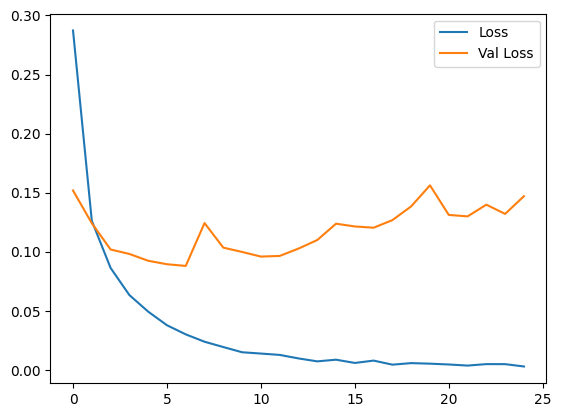

In [113]:
plt.plot(history.history['loss'], label = 'Loss')
plt.plot(history.history['val_loss'], label = 'Val Loss')
plt.legend()
plt.show()

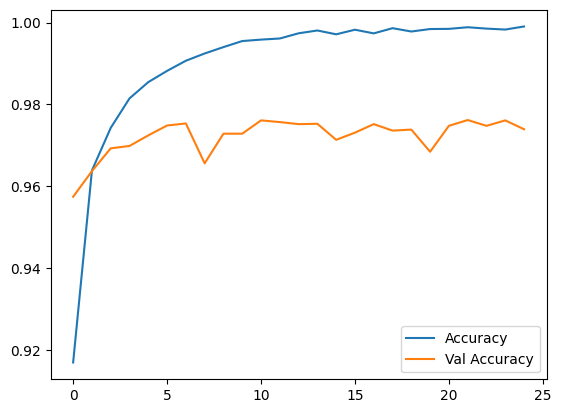

In [114]:
plt.plot(history.history['accuracy'], label = 'Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Val Accuracy')
plt.legend()
plt.show()

### Note :- Check with changing number of perceptrons in hidden layers, Increasing Hidden Layers and Increasing Epochs.

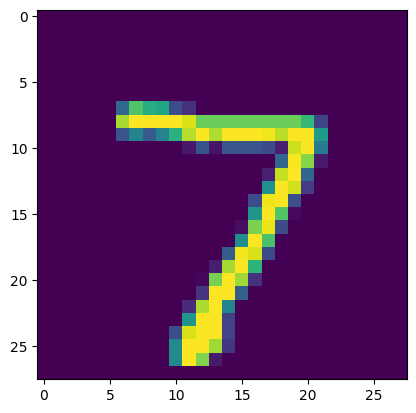

In [115]:
plt.imshow(X_test[0])

In [117]:
model.predict(X_test[0].reshape(1, 28, 28)).argmax(axis = 1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


array([7])